<a href="https://colab.research.google.com/github/rajiv-ranjan/cds-mini-projects/blob/Archana/M5_NB_MiniProject_02_Fare_Amount_Prediction_Using_Dask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini Project: Implementation of Linear Regression on a Large Dataset Using Dask Library

## Learning Objectives

At the end of the mini-project, you will be able to :

- understand how dask handles large dataset over pandas dataframe
- perform exploratory data analysis on a large dataset (2 Million rows) using dask
- implement linear regression model using dask library and make predictions


## Problem Statement

 Predict the taxi fare amount in New York city using Dask-ML.

## Information

### Dask
[Dask](https://dask.pydata.org/en/latest/) is an open source project that gives abstractions over NumPy Arrays, Pandas Dataframes and regular lists, allowing you to run operations on them in parallel, using multicore processing.

We can summarize the basics of Dask as follows:

* processes data that doesn’t fit into memory by breaking it into blocks and specifying task chains

* parallelizes execution of tasks across cores and even nodes of a cluster

* moves computation to the data rather than the other way around, to minimize communication overhead

### Dataset

The dataset is based on the 2016 NYC Yellow Cab trip record data made available in Big Query on Google Cloud Platform. Its variables are as follows:
![Dataset](https://cdn.exec.talentsprint.com/static/cds/NYC_Taxi_data_description_image.png)




Note that the features the ' Dask_MP_dataset.csv' file that is provided for this miniproject varies slightly in terms of included features, as compared to the original dataset described above. Please proceed with the provided csv file.

## Grading = 10 Points

In [ ]:
#@title Install Dask dependencies and restart runtime
!pip -qq install dask-ml
!pip -qq install dask
!pip -qq install dask[complete]
!pip install --upgrade --force-reinstall dask distributed
!pip -qq install mimesis

  Using cached dask-2025.5.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached distributed-2025.5.1-py3-none-any.whl.metadata (3.4 kB)
  Using cached click-8.2.1-py3-none-any.whl.metadata (2.5 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached fsspec-2025.5.1-py3-none-any.whl.metadata (11 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached partd-1.4.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached PyYAML-6.0.2-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached toolz-1.0.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached importlib_metadata-8.7.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached locket-1.0.0-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached msgpack-1.1.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.4 kB)
  Using cached psutil-7.0.0-cp36-abi3-manylinux_2_12_x86_64.manyl

#### Importing Necessary Packages

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import dask
import dask.dataframe as dd
import dask.array as da
from dask_ml.linear_model import LinearRegression
from dask_ml.model_selection import train_test_split
from dask_ml.metrics import mean_squared_error, r2_score
from dask.distributed import Client
import time as time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from dask.distributed import Client, progress
client = Client()

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-hp95bpqg', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-5tctjidc', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-yp_a_0bx', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-j1q90w1q', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-ciq21_f5', purging
INFO:distributed.diskutils:Found stale lock file and directory '/tmp/dask-scratch-space/worker-r3mo991w', purging
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:37641
INFO:distributed.scheduler:  dashboard at:  http://

In [ ]:
#@title Download the data
!wget https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Dask_MP_dataset.csv

--2025-05-25 03:16:49--  https://cdn.iisc.talentsprint.com/CDS/MiniProjects/Dask_MP_dataset.csv
Resolving cdn.iisc.talentsprint.com (cdn.iisc.talentsprint.com)... 172.105.52.210
Connecting to cdn.iisc.talentsprint.com (cdn.iisc.talentsprint.com)|172.105.52.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 231900522 (221M) [application/octet-stream]
Saving to: ‘Dask_MP_dataset.csv.4’

Dask_MP_dataset.csv 100%[===================>] 221.16M  10.7MB/s    in 22s     

2025-05-25 03:17:13 (9.85 MB/s) - ‘Dask_MP_dataset.csv.4’ saved [231900522/231900522]



#### Exercise 1: Read the dataset using dask library and compare the time of execution with pandas library. (1 Point)

**Hint:** pass `dtype` for passenger_count as `int64`

In [ ]:
dtypes = {'passenger_count': 'int64'}
start_dask = time.time()
dask_df = dd.read_csv("Dask_MP_dataset.csv", dtype=dtypes)
dask_time = time.time() - start_dask
print(f"Time to read with Dask: {dask_time:.4f} seconds")

Time to read with Dask: 0.0589 seconds


#### Use pandas to read the dataset and compare the time taken

In [ ]:
# --- Read with Pandas ---
start_pandas = time.time()
pandas_df = pd.read_csv("Dask_MP_dataset.csv", dtype=dtypes)
pandas_time = time.time() - start_pandas
print(f"Time to read with Pandas: {pandas_time:.4f} seconds")

Time to read with Pandas: 3.7734 seconds


Dask uses lazy evaluation, so read_csv only sets up a task graph, not actual reading.

Actual computation (e.g., .compute(), .head()) will take time.

In [ ]:
pandas_df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


### Data Analysis



#### Exercise 2: Drop the unnecessary columns. Also drop the duplicate rows and the rows having null values. (1 Point)

**Hint:** Drop those columns which are not useful in EDA as well as model implementation

In [ ]:
""" Drop unnecessary columns """
columns_to_drop = ['key']
dask_df = dask_df.drop(columns=columns_to_drop, errors='ignore')

In [ ]:
""" Drop duplicate rows """
dask_df = dask_df.drop_duplicates()

In [ ]:
""" drop NA rows """
dask_df = dask_df.dropna()

#### Exercise 3: Visualize the target variable, i.e., `fare_amount` to study the fare distribution, using a histogram density plot. Analyze the fare_amount distribution, try to visualize it for a range of [0, 60]. (1 Point)

**Hint:** [sns.hisplot()](https://stackoverflow.com/questions/51027636/seaborn-histogram-with-bigdata/51027895) and use `.between` to plot the graph for given range


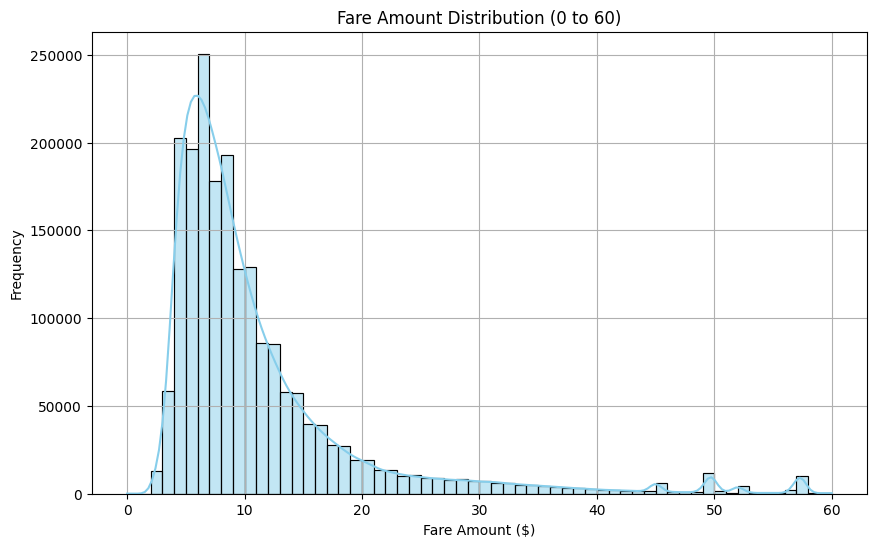

In [ ]:
""" explore and plot the density plot of fare_amount """
# Compute only the 'fare_amount' column to minimize memory usage
fare_data = dask_df['fare_amount'].compute()

# Filter fare values between 0 and 60
filtered_fare = fare_data[fare_data.between(0, 60)]

# Plot histogram with density
plt.figure(figsize=(10, 6))
sns.histplot(filtered_fare, bins=60, kde=True, color='skyblue')
plt.title("Fare Amount Distribution (0 to 60)")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()# YOUR CODE HERE

It is a right-skewed.Peaks around base fares($5-$15).

#### Observe the number of workers and cores running in your machine

Initialize a client and observe how many workers are working and the number of cores utilizing for the given data set.

In [ ]:
""" Initialize a client """
# Initialize Dask client
client = Client()

# Display the client dashboard information
client

INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:34195
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:42947/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:40007'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:34161'
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44037 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44037
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:55016
INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:35927 name: 1
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:35927
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:55032
INFO:distributed.scheduler:Receive client connection: Client-37132541-3916-11f0-8b0f-0242ac1c000c
INFO:distributed.core:Starting establis

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:42947/status,
Dashboard: http://127.0.0.1:42947/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34195,Workers: 0
Dashboard: http://127.0.0.1:42947/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44037,Total threads: 1
Dashboard: http://127.0.0.1:39741/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:40007,


### EDA based on Time

#### Exercise 4: Extract day of the week (dow), hour, month and year from `pickup_datetime`. (1 Point)

**Hint:** use `pd.to_datetime()` function as dask does not have this functionality in it.

Remember to use `.compute()` while passing the dask dataframe in defined function.

In [ ]:
import pandas as pd

# Step 1: Compute Dask dataframe to Pandas for time operations
df_pandas = dask_df.compute()

# Step 2: Convert pickup_datetime to proper datetime format
df_pandas['pickup_datetime'] = pd.to_datetime(df_pandas['pickup_datetime'])

# Step 3: Extract new time features
df_pandas['hour'] = df_pandas['pickup_datetime'].dt.hour
df_pandas['day_of_week'] = df_pandas['pickup_datetime'].dt.dayofweek
df_pandas['month'] = df_pandas['pickup_datetime'].dt.month
df_pandas['year'] = df_pandas['pickup_datetime'].dt.year

# Display to verify
df_pandas[['pickup_datetime', 'hour', 'day_of_week', 'month', 'year']].head()

,pickup_datetime,hour,day_of_week,month,year
1,2010-01-05 16:52:16+00:00,16,1,1,2010
4,2010-03-09 07:51:00+00:00,7,1,3,2010
8,2012-12-03 13:10:00+00:00,13,0,12,2012
15,2013-11-23 12:57:00+00:00,12,5,11,2013
16,2014-02-19 07:22:00+00:00,7,2,2,2014


#### Exercise 5: a.) Plot the taxi trip by hour of the day  (0.5 Points)

* Partition the data into segments using `dask.from_pandas()`

* Plot the taxi trip for hour of the day. **Hint:** [sns.catplot](https://seaborn.pydata.org/generated/seaborn.catplot.html)

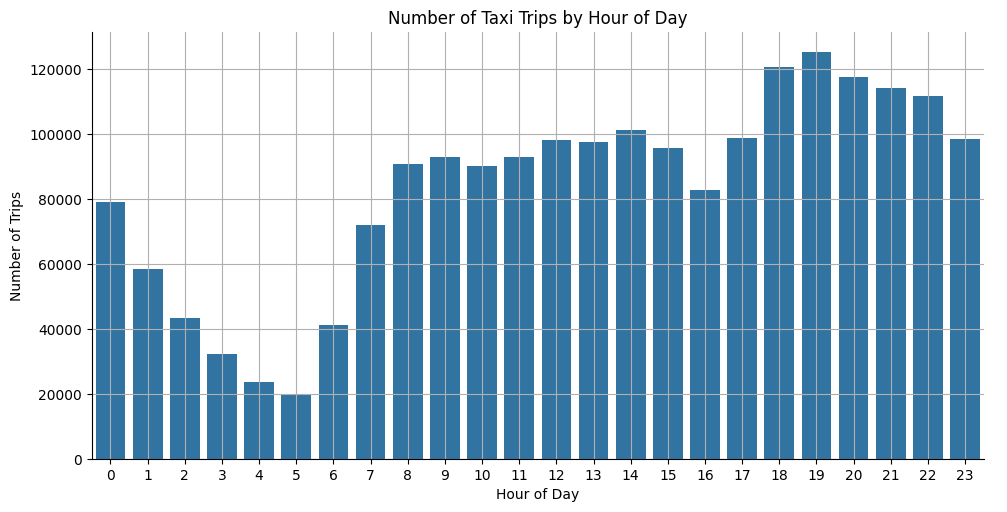

In [ ]:
""" taxi trip repartition by hour of the day """


# Convert pandas DataFrame back to Dask
dask_df = dd.from_pandas(df_pandas, npartitions=4)
#Count number of trips per hour
#Since Seaborn needs Pandas, we’ll compute the hourly counts with Dask, then convert that summary to Pandas:
# Group by hour and count trips
hourly_trip_counts = dask_df.groupby('hour').size().compute().reset_index(name='trip_count')
#Plot using Seaborn's catplot
# Plot the number of trips per hour
sns.catplot(data=hourly_trip_counts, x='hour', y='trip_count', kind='bar', height=5, aspect=2)
plt.title("Number of Taxi Trips by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

#### Exercise 5: b.) Plot the taxi trip repartition by day of the week (dow) (0.5 Points)

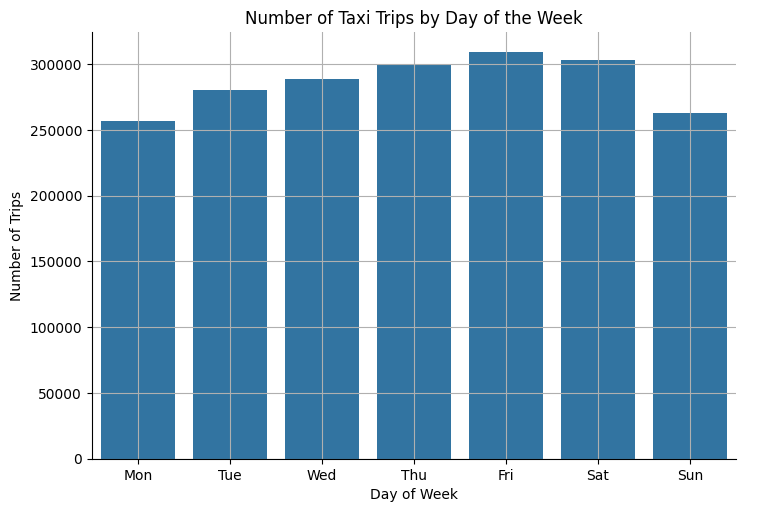

In [ ]:
""" taxi trip repartition by day of the week """
# Step 1: Group by day of the week and count trips
# Group by day_of_week and count trips
dow_trip_counts = dask_df.groupby('day_of_week').size().compute().reset_index(name='trip_count')
# Create a categorical label for days (optional, for clearer plot labels)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_trip_counts['day_label'] = dow_trip_counts['day_of_week'].map(dict(enumerate(days)))

# Plot bar chart
sns.catplot(data=dow_trip_counts, x='day_label', y='trip_count', kind='bar', height=5, aspect=1.5)
plt.title("Number of Taxi Trips by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

#### Exercise 6: a.) Draw a plot between the target variable and passenger count and analyze it.  (0.5 Points)

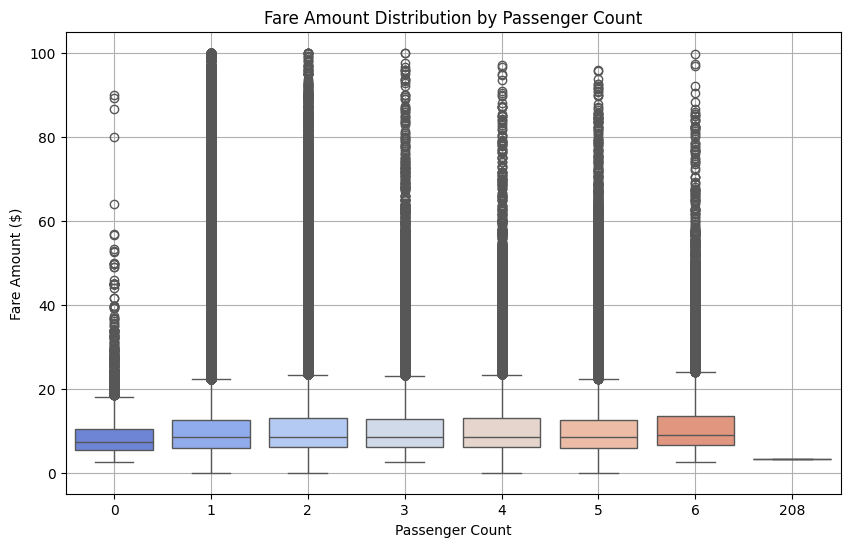

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter data to avoid extreme fare values for clearer visualization
filtered_df = df_pandas[df_pandas['fare_amount'].between(0, 100)]

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_df, x='passenger_count', y='fare_amount', palette='coolwarm')
plt.title("Fare Amount Distribution by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount ($)")
plt.grid(True)
plt.show()

#### Exercise 6: b.) Draw a plot between the target variable and hour and analyze it. (0.5 Points)

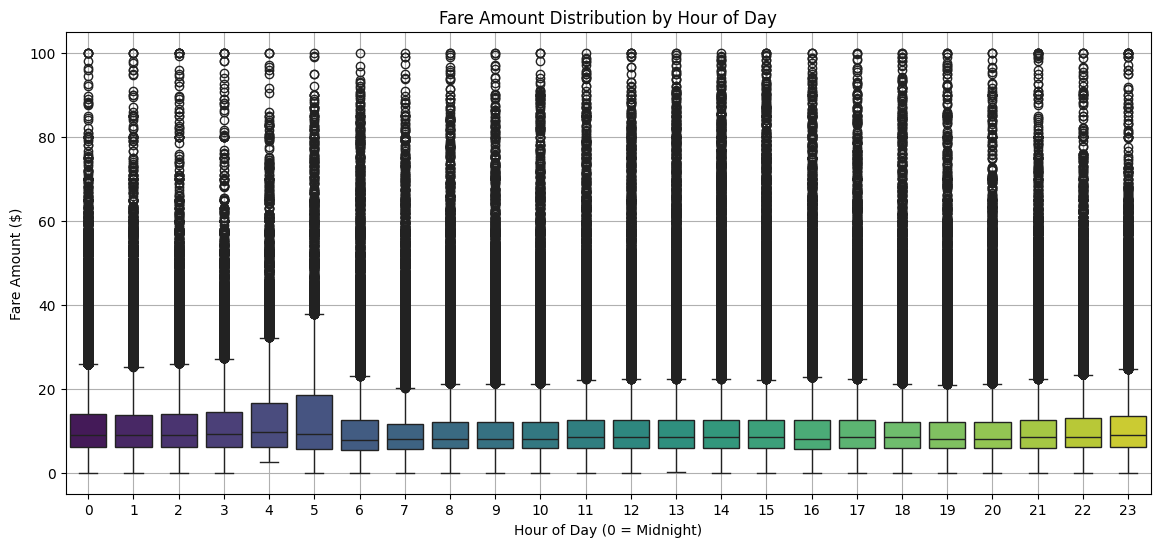

In [ ]:
""" fare amount by hour """
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out extreme fares to make the plot readable (optional)
filtered_df = df_pandas[df_pandas['fare_amount'].between(0, 100)]

# Create the boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=filtered_df, x='hour', y='fare_amount', palette='viridis')
plt.title("Fare Amount Distribution by Hour of Day")
plt.xlabel("Hour of Day (0 = Midnight)")
plt.ylabel("Fare Amount ($)")
plt.grid(True)
plt.show()

### Feature Engineering

#### Exercise 7: Compute the Haversine distance between pickup and dropoff point. (1 Point)

* Convert the latitude and longitude co-rodinates to radians

* Calculate the Haversine distance

  **Hint:** [haversine_distances](https://towardsdatascience.com/heres-how-to-calculate-distance-between-2-geolocations-in-python-93ecab5bbba4)

* Add the "distance" feature to the dataset and plot its distribution

In [ ]:
""" distance feature """
from sklearn.metrics.pairwise import haversine_distances

# Filter out extreme fares to make the plot readable (optional)
df_pandas = df_pandas[df_pandas['fare_amount'].between(0, 50)]

# Create array of pickup and dropoff coordinates (in radians)
pickup_coords = np.radians(df_pandas[['pickup_latitude', 'pickup_longitude']])
dropoff_coords = np.radians(df_pandas[['dropoff_latitude', 'dropoff_longitude']])

# Compute haversine distance (result is in radians of Earth radius)
radian_distances = haversine_distances(pickup_coords, dropoff_coords)

# Earth radius in kilometers
earth_radius = 6371

# Convert to kilometers
df_pandas['distance'] = radian_distances * earth_radius

NameError: name 'df_pandas' is not defined

In [ ]:
""" plot the distance feature (take distance < 50) """


# Filter out long-distance outliers
filtered_df = df_pandas[df_pandas['distance'] < 50]

# Plot the distribution of distances
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['distance'], bins=100, kde=True, color='teal')
plt.title("Distribution of Trip Distances (Under 50 km)")
plt.xlabel("Distance (km)")
plt.ylabel("Number of Trips")
plt.grid(True)
plt.show()

NameError: name 'df_pandas' is not defined

### Show the plot between distance and fare amount

**Hint:** [sns.scatterplot()](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)

In [ ]:
""" correlation between fare_amount and distance """


# Filter for meaningful data
filtered_df = df_pandas[
    (df_pandas['distance'] < 50) &
    (df_pandas['fare_amount'] > 0) &
    (df_pandas['fare_amount'] < 100)
]

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=filtered_df, x='distance', y='fare_amount', alpha=0.4, color='purple')
plt.title("Scatter Plot: Distance vs Fare Amount")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount ($)")
plt.grid(True)
plt.show()

Pattern to Look For	What It Might Mean
Linear Trend	More distance = more fare (expected)
Flat Fare Bands	Fixed pricing for certain distances (e.g., airport trips)
Outliers	High fare, low distance? Might be data errors or surcharges

This plot is a good sanity check before modeling. A clear positive relationship helps justify using distance as a feature in your regression model.

### Preparing dataset for model implementation

**Note:** Use the above modified dataset for modelling.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features and target
features = ['passenger_count', 'hour', 'day_of_week', 'month', 'year', 'distance']
target = 'fare_amount'

# Drop rows with missing values in selected columns
df_model = df_pandas[features + [target]].dropna()
# Optional: remove 0 or negative fares/distances
df_model = df_model[
    (df_model['fare_amount'] > 0) &
    (df_model['distance'] > 0) &
    (df_model['distance'] < 50)
]
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Feature Scaling
#If you use models like Linear Regression, it helps to scale numeric features:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

NameError: name 'df_pandas' is not defined

### Removing outliers from training set Based on Coordinates

#### Exercise 8: Remove the outliers using the given latitude and longitude features from the dataset. We need to analyze the data of taxi within New York City. (1 Point)

**Hint:** Given the co-ordinates of New York city are Latitude: 40.7128° and Longitude: -74.0060°. You can include the pickup and drop off points such that there left and right value mean will be the given co-ordinate value.

Also, choose nearest extreme values.

Use `.between()` and pass left and right value attributes accordingly.

In [ ]:
""" remove the outliers in pickup latitude longitude and drop off latitude and longitude """
# Define bounding box for NYC area
lat_min, lat_max = 40.5, 41.0
lon_min, lon_max = -74.25, -73.70

# Filter pickup and dropoff locations within bounds
df_pandas = df_pandas[
    df_pandas['pickup_latitude'].between(lat_min, lat_max) &
    df_pandas['pickup_longitude'].between(lon_min, lon_max) &
    df_pandas['dropoff_latitude'].between(lat_min, lat_max) &
    df_pandas['dropoff_longitude'].between(lon_min, lon_max)
]
#Reset index after filtering
df_pandas = df_pandas.reset_index(drop=True)

NameError: name 'df_pandas' is not defined

### Modelling

#### Exercise 9: Divide the data into train and test splits with X as feature variables and y as target variable  (1 Point)

* Divide data into train test split with 70-30 ratio, Hint: `train_test_split()`

* As dask functions operate lazily so, before calling `.fit()` function, call the dask dataframe with `.compute()`.
* Convert X_train and y_train into array using `.values` as [dask's](https://ml.dask.org/modules/api.html) `.fit()` function takes array as attribute

In [ ]:
""" select the target and feature variables and split the data into train and test """
# Define your features and target
features = ['passenger_count', 'hour', 'day_of_week', 'month', 'year', 'distance']
target = 'fare_amount'

X = dask_df[features]
y = dask_df[target]

X = X.compute()
y = y.compute()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Convert to arrays as some models (like Dask-ML or NumPy-based) require this
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

#### Exercise 10: Predict the test data and calculate the mean squared error and r2 score. (1 Point)

**Hint:** Remember to call `.compute()` function as dask functions operate lazily and convert the dask dataframe to `.values` (Array type) as suggested in above exercise

In [ ]:
""" predict the values """
from sklearn.metrics import mean_squared_error, r2_score

# Assuming you have a fitted model called 'model'
# and test features 'X_test' (Dask dataframe)
# and test targets 'y_test' (Dask dataframe)

# Predict on test data (Dask lazy)
y_pred = model.predict(X_test)

# Compute the predictions to get a NumPy array
y_pred = y_pred.compute()

# Also compute y_test and convert to numpy array
y_true = y_test.compute().values



In [ ]:
""" compute mean squared error and r2_score """
# Calculate metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

### Report Analysis
* Discuss the pros and cons of using dask
* Derive the insights and discuss
* Comment on the performance metrics (MSE, $R^2$ score)
